In [1]:
## 4.1.1 Charger les packages
#Pour exécuter cette analyse, lancez toutes les cellules du notebook, en commençant par la cellule « Charger les packages ».
#_______________________________________________

%matplotlib inline


import datacube

import xarray as xr

import geopandas as gpd

import matplotlib.pyplot as plt

from odc.geo.geom import Geometry

 

from deafrica_tools.datahandling import load_ard, mostcommon_crs

from deafrica_tools.plotting import rgb

from deafrica_tools.bandindices import calculate_indices

from deafrica_tools.areaofinterest import define_area

#_____________________________________________

In [2]:
## 4.1.2 Se connecter au datacube
#_______________________________________________
dc = datacube.Datacube(app='crop_health_evi')
#_______________________________________________

In [3]:
## 4.1.3 Définir les paramètres d’analyse
#La cellule suivante définit les paramètres qui permettent de déterminer la zone d’intérêt et la période d’analyse. Ces paramètres sont :

#lat: la latitude centrale à analyser (ex.: 10.338).
#lon: la longitude centrale à analyser (ex.: 1.055).
#buffer:  la zone (en degrés carrés) à charger autour du point central. Pour des temps de chargement raisonnables, utilisez une valeur de 0.1 ou moins.
#Sélection de la zone d’étude
#Deux méthodes sont disponibles pour définir la zone d’intérêt :

#En spécifiant la latitude, la longitude et la valeur du buffer (en degrés carrés). Cette méthode nécessite de saisir les coordonnées latitudinales et longitudinales centrales, ainsi que la valeur du buffer (en degrés carrés) autour du point que vous souhaitez analyser. Par exemple, les coordonnées lat = 10.338, lon = -1.055 et buffer = 0.1 sélectionneront une zone avec un rayon de 0,1 degré autour du point de coordonnées (10.338, -1.055).
#Alternativement, vous pouvez définir séparément un buffer pour la latitude et un autre pour la longitude, afin d’obtenir une zone rectangulaire. Par exemple, les valeurs lat = 10.338, lon = -1.055, lat_buffer = 0.1 et lon_buffer = 0.08 sélectionneront une zone s’étendant de 0,1 degré au nord et au sud, et de 0,08 degré à l’est et à l’ouest à partir du point  (10.338, -1.055).
#Pour un temps de chargement raisonnable, il est conseillé de garder le buffer inférieur ou égal à  0.1.
#En uploadant un polygone au format GeoJSON ou Shapefile Esri. Si vous choisissez cette option, vous devrez utiliser le bouton Upload Files situé en haut à gauche de l’interface Jupyter Notebook pour télécharger le fichier GeoJSON ou Shapefile ESRI dans le Sandbox. Les shapefiles ESRI doivent impérativement être uploadés avec tous les fichiers associés : (.cpg, .dbf, .shp, .shx). Une fois le fichier importé, vous pourrez l'utiliser pour définir votre zone d'intérêt. N’oubliez pas de mettre à jour le code pour appeler le fichier que vous avez téléchargé.
#Pour utiliser l’une de ces méthodes, vous devez décommenter la ligne de code correspondante et commenter l’autre. Pour commenter une ligne, ajoutez le symbole "#" au début de celle que vous souhaitez désactiver. Par défaut, la première option (qui permet de définir la localisation à l’aide de la latitude, de la longitude et d’un buffer) est utilisée.


#Si vous exécutez le notebook pour la première fois, laissez les paramètres par défaut. Cela permettra de montrer comment fonctionne l’analyse et de produire des résultats pertinents.


#_________________________________________________________

# Méthode 1 : spécifier la latitude, la longitude et le buffer 

#aoi = define_area(lat=-1.7978, lon=37.7311, buffer=0.02)

 

# Méthode 2 : utiliser un polygone sous forme de GeoJSON ou de fichier shapefile Esri  

aoi = define_area(vector_path='/home/jovyan/projet_sig/Kit_climat_action/Session4/data/Complexe_PONASI.geojson')

 

# Créer un géopolygone et un GeoDataFrame pour la zone d’intérêt 4326 32630

geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")

geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

 

# Obtenir les bornes de latitude et de longitude du géopolygone

lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])

lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

#_________________________________________________________

In [4]:
## 4.1.4 Créer une requête et charger les données satellitaires
#La fonction load_ard masque automatiquement les nuages dans le jeu de données, ce qui permet de se concentrer sur les pixels contenant des informations utiles. Elle exclut également les images dont plus de 99 % des pixels sont masqués, grâce au paramètre min_gooddata utilisé lors de l'appel de load_ard.
#_________________________________________________________

# Créer une requête réutilisable

query = {

    'x': lon_range,

    'y': lat_range,

    'time': ('2022'),

    'resolution': (500, 500)

}

 

# Identifier le système de projection le plus courant dans la requête

output_crs = mostcommon_crs(dc=dc, product='ls9_sr', query=query)

 

# Charger les données disponibles de Landsat 9 et filtrer pour ne conserver

# que les dates avec au moins 99 % de bonnes données

ds = load_ard(dc=dc,
              products=['ls9_sr'],

              min_gooddata=0.99,

              measurements=['red', 'green', 'blue', 'nir'],

              output_crs=output_crs,              **query)

#_________________________________________________________


Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls9_sr
Counting good quality pixels for each time step


/opt/venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Filtering to 94 out of 160 time steps with at least 99.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Loading 94 time steps


In [5]:
## 4.1.4 Créer une requête et charger les données satellitaires
#La fonction load_ard masque automatiquement les nuages dans le jeu de données, ce qui permet de se concentrer sur les pixels contenant des informations utiles. Elle exclut également les images dont plus de 99 % des pixels sont masqués, grâce au paramètre min_gooddata utilisé lors de l'appel de load_ard.
#_________________________________________________________

# Créer une requête réutilisable

query = {

    'x': lon_range,

    'y': lat_range,

    'time': ('2022'),

    'resolution': (500, 500)

}

 

# Identifier le système de projection le plus courant dans la requête

output_crs = mostcommon_crs(dc=dc, product='ls9_sr', query=query)

 

# Charger les données disponibles de Landsat 9 et filtrer pour ne conserver

# que les dates avec au moins 99 % de bonnes données

ds = load_ard(dc=dc,

              products=['ls9_sr'],

              min_gooddata=0.99,

              measurements=['red', 'green', 'blue', 'nir'],

              output_crs=output_crs,              **query)

#_________________________________________________________


Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls9_sr
Counting good quality pixels for each time step
Filtering to 94 out of 160 time steps with at least 99.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Loading 94 time steps


In [6]:
#_________________________________________________________
display(ds)
#_________________________________________________________

<xarray.Dataset> Size: 279MB
Dimensions:      (time: 94, y: 300, x: 619)
Coordinates:
  * time         (time) datetime64[ns] 752B 2022-01-04T10:32:31.284188 ... 20...
  * y            (y) float64 2kB 1.205e+06 1.205e+06 ... 1.354e+06 1.354e+06
  * x            (x) float64 5kB 5.208e+05 5.212e+05 ... 8.292e+05 8.298e+05
    spatial_ref  int32 4B 32630
Data variables:
    red          (time, y, x) float32 70MB nan nan nan nan ... nan nan nan nan
    green        (time, y, x) float32 70MB nan nan nan nan ... nan nan nan nan
    blue         (time, y, x) float32 70MB nan nan nan nan ... nan nan nan nan
    nir          (time, y, x) float32 70MB nan nan nan nan ... nan nan nan nan
Attributes:
    crs:           EPSG:32630
    grid_mapping:  spatial_ref

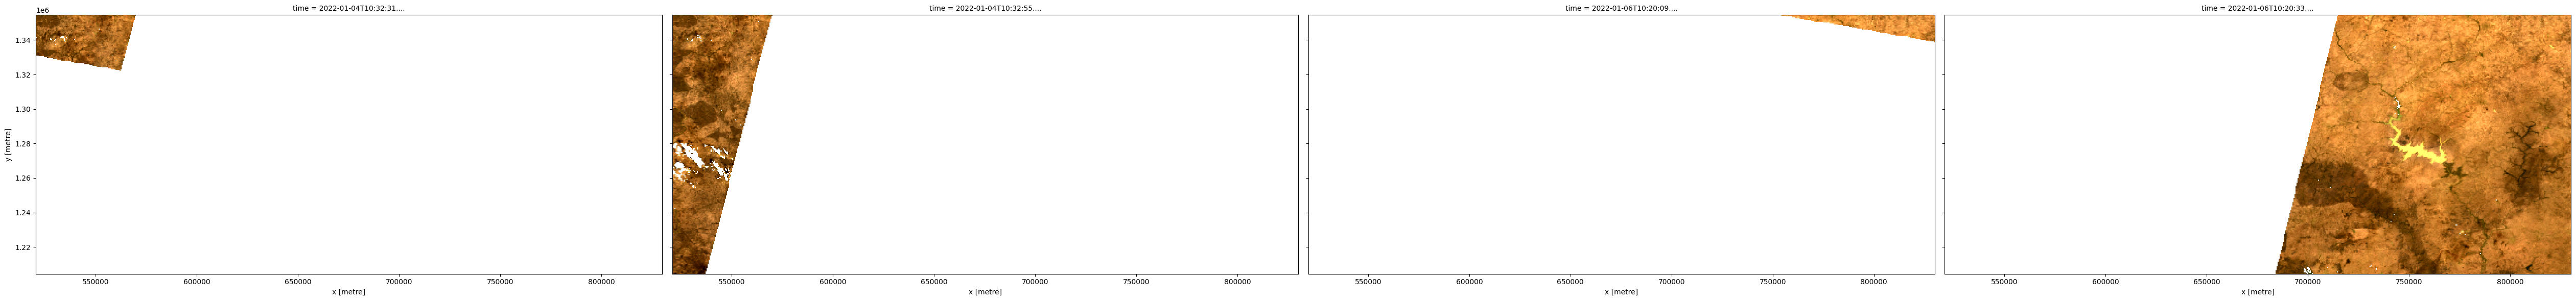

In [7]:
## 4.1.5 Afficher les images pour visualiser l’apparence de la zone
#Nous utilisons la fonction rgb pour afficher les pas de temps de notre jeu de données sous forme d’images RVB en vraies couleurs.

#_________________________________________________________

# Afficher une image en vraies couleurs (RVB)

rgb(ds, index=[0, 1, 2, 3])
#_________________________________________________________